In [1]:
model_slug = "Llama-3.2-1B-Instruct"

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load .pt file
data = torch.load(f"elicit-beliefs-{model_slug}.pt", weights_only=False)
logits = data["logits"]
top_other_logit = data["top_other_logit"]
top_other_id = data["top_other_id"]
top_other_token = data["top_other_token"]

In [3]:
from supporting_code import WORDS, YES, NO, TRUE, FALSE, PROMPT_TEMPLATES, logits_to_affirm_prob, present_results

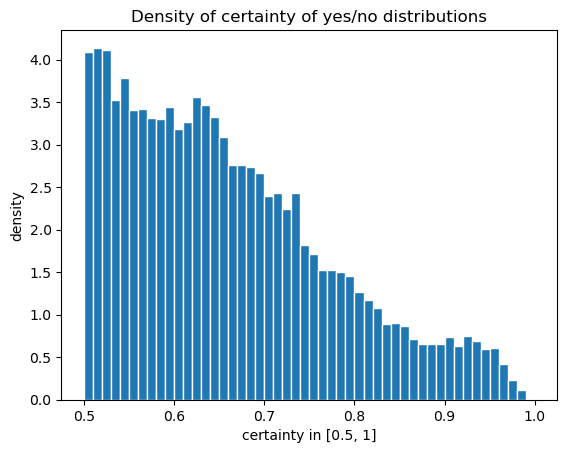

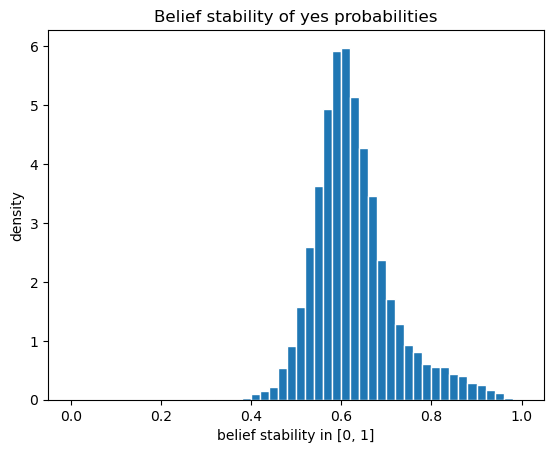

In [4]:
p_affirm = logits_to_affirm_prob(logits, prompts=[0, 1, 2, 3])
present_results(p_affirm)

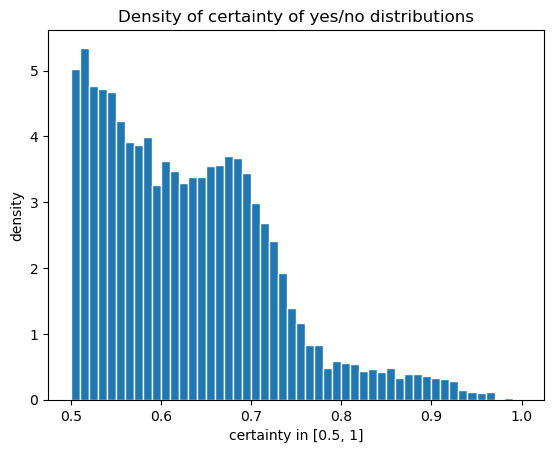

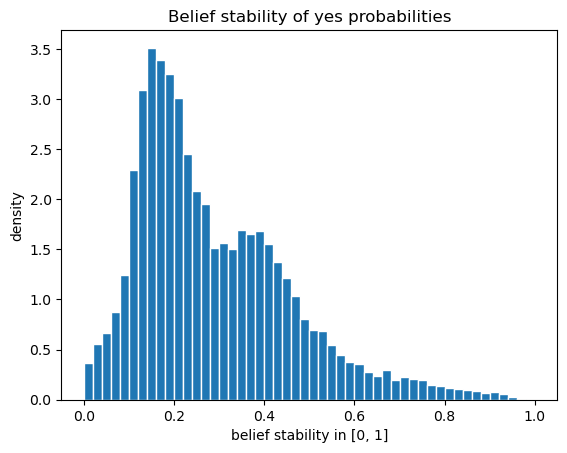

In [5]:
p_affirm = logits_to_affirm_prob(logits, prompts=[4, 5, 6, 7])
present_results(p_affirm)

In [6]:
all_logits = torch.hstack((logits, top_other_logit[:,None]))
all_probs = all_logits.softmax(axis=1)

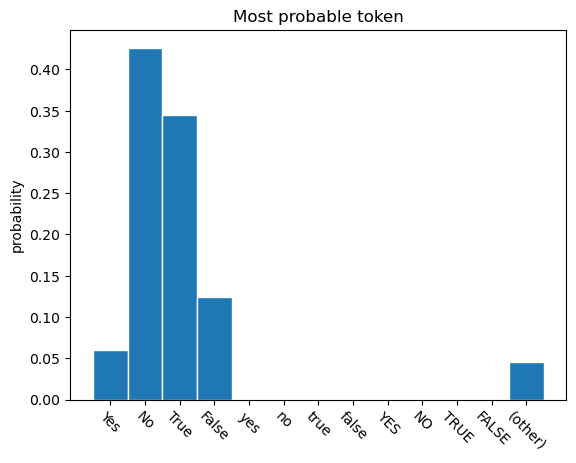

In [7]:
import matplotlib.pyplot as plt
import numpy as np
plt.title("Most probable token")
plt.hist(all_probs.argmax(dim=1), bins=np.arange(len(WORDS)+2) - 0.5, edgecolor='white', density=True)
plt.xticks(np.arange(len(WORDS)+1), WORDS + ["(other)"], rotation=-45)
plt.ylabel('probability')
plt.show()

In [8]:
# Most probable other token
from collections import Counter
Counter(top_other_token)

Counter({'I': 62880,
         '**': 18195,
         'Answer': 9030,
         'This': 4963,
         'The': 2845,
         'To': 1882,
         ' TRUE': 1355,
         ' False': 816,
         'That': 465,
         ' FALSE': 340,
         'B': 274,
         'T': 207,
         'Maybe': 198,
         'M': 169,
         'Correct': 165,
         'P': 154,
         'A': 132,
         'K': 106,
         'G': 106,
         'According': 104,
         'C': 97,
         'F': 94,
         'H': 90,
         'L': 83,
         'Port': 82,
         'Based': 81,
         'Al': 80,
         'D': 77,
         'O': 72,
         'S': 70,
         'R': 69,
         'Gu': 66,
         'Ch': 57,
         'X': 54,
         'Sh': 53,
         'N': 50,
         'Be': 47,
         'U': 41,
         'Or': 39,
         'Ar': 39,
         'There': 38,
         'Mal': 38,
         'Nov': 38,
         'Qu': 37,
         'E': 37,
         'Bar': 36,
         'De': 35,
         'Q': 34,
         'Mar': 34,
         'Ed':

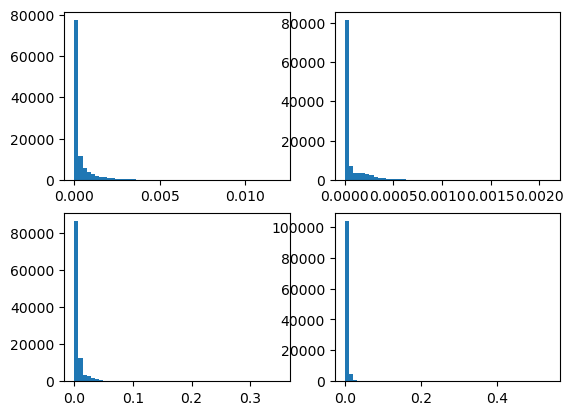

In [9]:
# histogram of yes/Yes, no/No, true/True, false/False
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.hist(all_probs[:, i+4] / all_probs[:, i], bins=50);
plt.show()

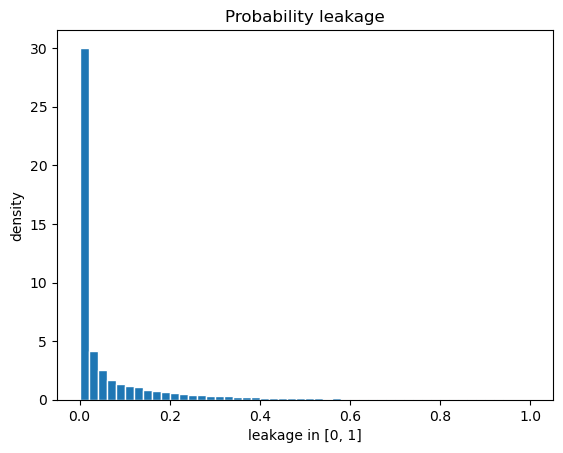

In [10]:
leakage = all_probs[:,-1]

plt.figure()
plt.title("Probability leakage")
plt.hist(leakage, bins=np.linspace(0, 1, 51), density=True, edgecolor="white")
plt.xlabel("leakage in [0, 1]")
plt.ylabel("density")

plt.show()

In [11]:
# Most probable token is other, what is it?
other_wins = (all_probs.argmax(axis=1) == len(WORDS)).argwhere()
Counter([top_other_token[i] for i in other_wins])

Counter({'**': 2340,
         'To': 1162,
         'I': 897,
         'This': 301,
         'The': 83,
         'Be': 8,
         'Act': 7,
         'Ap': 5,
         'Techn': 5,
         'Ed': 5,
         'Q': 4,
         'L': 4,
         'R': 4,
         'X': 3,
         'E': 3,
         'Mar': 3,
         'Ich': 3,
         'James': 3,
         'Diamond': 3,
         'Me': 3,
         'Sc': 3,
         'Dep': 2,
         'Based': 2,
         'G': 2,
         'B': 2,
         'Carl': 2,
         'Charles': 2,
         'Ha': 2,
         'In': 2,
         'Richard': 2,
         'Sum': 2,
         'D': 2,
         'H': 2,
         'Sir': 2,
         'W': 2,
         'Ag': 1,
         'Saint': 1,
         'K': 1,
         'Arthur': 1,
         'There': 1,
         'Warn': 1,
         'Hen': 1,
         'Gar': 1,
         'Am': 1,
         'A': 1,
         'Re': 1,
         'Ya': 1,
         'Will': 1,
         'Den': 1,
         'Lin': 1,
         'Wall': 1,
         'Gu': 1,
         'O